# Currents, barotropic streamfunction, SSH variability

Re-create [Kiss et al 2020](https://doi.org/10.5194/gmd-13-401-2020) figs 16, 17, 21, 22, 24

See
- https://github.com/COSIMA/ACCESS-OM2-1-025-010deg-report/blob/master/figures/BarotropicStreamfunction/BarotropicStreamfunction.ipynb
- https://github.com/COSIMA/ACCESS-OM2-1-025-010deg-report/blob/master/figures/Southwest_Atlantic/Southwest_atlantic_analysis_v3.ipynb

See
- https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/15
- https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/18

In [34]:
# These first two cells must be in all notebooks!
# It allows us to run all the notebooks at once, this cell has a tag "parameters" which allows us to pass in 
# arguments externally using papermill (see mkfigs.sh for details)

# Set esm_file to the datastore for the main experiment of interest
# esm_file = "/g/data/ol01/outputs/access-om3-25km/25km-iaf-test-for-AK-expt-7df5ef4c/datastore.json"
# esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-5165c0f8/datastore.json"
# esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/datastore.json"
esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test4-d28e0359/datastore.json"
#esm_file = "/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-03-06-2026/cm3-datastore/cm3-datastore.json"

# papermill settings. *No need to modify these if running interactively.* 
papermill = False                      # `cwd` and `nbname` will be populated by papermill.
cwd = None                             # current working directory 
nbname = None                          # notebook name

In [35]:
import os
if not papermill: 
    import nci_ipynb  # requires conda/analysis3-26.03 or later
    cwd = nci_ipynb.dir()
    nbname = nci_ipynb.name()
    os.chdir(cwd)
import mkfigs_bootstrap  # noqa: adds external/access-model-mkfigs/src to sys.path (stop-gap)
from mkfigs import MkmdWriter
mkmd = MkmdWriter(esm_file, nbname, str(cwd), pm=papermill)
from exptdata_access import guess_experiment_from_esm_file
expt_key, info = guess_experiment_from_esm_file(esm_file)
model_name = info["model"]  # OM3 or CM3

In [36]:
from model_agnostic import patch_broken_conda_env, patch_dask_workers
patch_broken_conda_env()  # conda env workaround; no-op on healthy envs

import xarray as xr
import gsw
import intake
from dask.distributed import Client
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import cmocean as cm
import cartopy.crs as ccrs
import cartopy.feature as cft
from shapely import geometry
import calendar
import cftime
import textwrap
import numpy as np
from tqdm.notebook import tqdm
import xgcm
from scipy.io import loadmat

In [37]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [38]:
xr.set_options(keep_attrs=True);

In [39]:
client = Client(threads_per_worker=1)
patch_dask_workers(client)  # patch workers too
print(client.dashboard_link)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38809 instead
  warnings.warn(


/proxy/38809/status


In [40]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/38809/status,
Dashboard: /proxy/38809/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34303,Workers: 0
Dashboard: /proxy/38809/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33265,Total threads: 1
Dashboard: /proxy/35539/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:32997,


In [41]:
IAF = esm_file.find('iaf') > 0
IAF

True

In [42]:
om3exptname = os.path.basename(os.path.dirname(esm_file))
om3exptname

'MC_25km_jra_iaf+wombatlite-test4-d28e0359'

## Load ACCESS-OM3 data from ESM datastore

In [43]:
exptname = os.path.basename(os.path.dirname(esm_file))

In [44]:
catalogs = [
                # '/g/data/ol01/access-om3-output/access-om3-025/25km-iaf-test-for-AK-expt-7df5ef4c/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-5165c0f8/datastore.json',
                esm_file,
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm1-d968c801/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm2-5dc49da6/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm3-da330542/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm4-9fd08880/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm5-9b5dbfa9/datastore.json',
            ]
catalogs

['/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test4-d28e0359/datastore.json']

In [45]:
om3datastores = { os.path.normpath(c).split(os.sep)[-2]:
               intake.open_esm_datastore(c,
                                         columns_with_iterables=[
                                            "variable",
                                            "variable_long_name",
                                            "variable_standard_name",
                                            "variable_cell_methods",
                                            "variable_units"]
                                        )
              for c in catalogs }
om3datastores

{'MC_25km_jra_iaf+wombatlite-test4-d28e0359': <datastore catalog with 24 dataset(s) from 32795 asset(s)>}

In [46]:
fields = { # key is OM3 name, value is OM2 name
    "speed": None,  # presumably includes high-frequency motion, so differs from sqrt(uo**2 + vo**2) calculated from monthly means
    "uo": "u",
    "vo": "v",
    "umo_2d": None,
    "vmo_2d": None,
    "zos": None,
    "zossq": None,
}

open_kwargs = dict(
    # chunks={"xh": -1, "yh": -1},
    # chunks={"time": -1},
    decode_timedelta=True,
    use_cftime=True
)
if model_name == "ACCESS-CM3":
    open_kwargs["chunks"] = {"time": 1}  # CM3 stores yearly files

data = {
    vname: {expt: ds.search(variable=vname, frequency="1mon").to_dask(
                xarray_open_kwargs = open_kwargs
            )[vname]
            for expt, ds in om3datastores.items()
          }
    for vname in fields
    }

# uo/vo are only plotted at 2 depths; select them now (before the time mean)
# so only those levels are read, not all 75
for vname in ["uo", "vo"]:
    for expt in data[vname]:
        data[vname][expt] = data[vname][expt].sel(z_l=[0, 1000], method="nearest")

# omit latitudes with grid bug in this run https://github.com/ACCESS-NRI/ocean_model_grid_generator/issues/7
for vname, d in data.items():
    try:
        d['25km-iaf-test-for-AK-expt-7df5ef4c'] = d['25km-iaf-test-for-AK-expt-7df5ef4c'].isel(yh=slice(10, None))
    except ValueError:
        d['25km-iaf-test-for-AK-expt-7df5ef4c'] = d['25km-iaf-test-for-AK-expt-7df5ef4c'].isel(yq=slice(10, None))
    except KeyError:
        pass

if IAF:
    for vname, d in data.items():
        for expt in d:
            try:
                d[expt] = d[expt].convert_calendar("proleptic_gregorian", use_cftime=True)
            except KeyError:
                pass

### Trim to a consistent time range

In [47]:
# find largest overlapping time range

# earliest end date in data
datastop = np.min([ data['uo'][e].time.values[-1] for e in data['uo'].keys() ])

# latest start date in data
datastart = np.max([ data['uo'][e].time.values[0] for e in data['uo'].keys() ])

print('common data range:', datastart, ' to ', datastop)

nyears = 30
datastart = np.max([
    datastart, 
    cftime.datetime(cftime.to_tuple(datastop)[0]-nyears+1, 1, 1, calendar=datastop.calendar)
])

# bracket to start/end of year
datestart = cftime.datetime(cftime.to_tuple(datastart)[0],  1, 1, calendar=datastop.calendar)
datestop  = cftime.datetime(cftime.to_tuple(datastop)[0], 12, 31, 23, 59, 59, calendar=datastop.calendar)

timeslice = slice(datestart, datestop)
timeslice

common data range: 1958-01-16 12:00:00  to  2023-12-16 12:00:00


slice(cftime.datetime(1994, 1, 1, 0, 0, 0, 0, calendar='proleptic_gregorian', has_year_zero=True), cftime.datetime(2023, 12, 31, 23, 59, 59, 0, calendar='proleptic_gregorian', has_year_zero=True), None)

In [48]:
# trim everything to timeslice and time-average
data = { vname: {expt: da.sel(time=timeslice).mean('time') for expt, da in dct.items()} for vname, dct in data.items() }

### Load OM3 grid data

In [49]:
# regex matches access-om3 and access-cm3 static files
static = xr.open_dataset(om3datastores[exptname].search(filename=".*mom6.static.nc").df.loc[0, "path"]).drop_vars("time")

In [50]:
# See https://xgcm.readthedocs.io/en/latest/xgcm-examples/03_MOM6/#xgcm-grid-definition
symmetric = True  # True for ACCESS-OM3 2025.08.000 and later

if symmetric:  # ACCESS-OM3 version 2025.08.000 and later: one more q point than h points
    coords={
        'X': {'center': 'xh', 'outer': 'xq'},
        'Y': {'center': 'yh', 'outer': 'yq'},
        # 'Z': { 'inner': 'z_l', 'outer': 'z_i'}
    }
else:  # ACCESS-OM3 versions prior to 2025.08.000: equal number of q and h points
    coords={
        'X': {'center': 'xh', 'right': 'xq'},
        'Y': {'center': 'yh', 'right': 'yq'},
        # 'Z': { 'inner': 'z_l', 'outer': 'z_i'}
    }

grid = xgcm.Grid(
    static,
    coords=coords,
    metrics = {
        ('X',): ['dxt', 'dxCu', 'dxCv'], # X distances
        ('Y',): ['dyt', 'dyCu', 'dyCv'], # Y distances
        ('X', 'Y'): ['areacello', 'areacello_cu', 'areacello_cv', 'areacello_bu'] # Areas
    },
    periodic=['X'],
    autoparse_metadata=False
# Note, autoparse_metadata=False is required below for xgcm >= 0.9.0 to prevent xgcm 
# from trying to autoparse non-existent grid information from the file metadata, 
# leading to the error:
# ValueError: Found two coordinates without `c_grid_axis_shift` attribute for axis X
)

### Load observations

In [51]:
def xtile(ds_in, x="longitude"):
    """
    Tile dataset in longitude to cover MOM6 range.
        ds_in: input dataset, assumed 2d with x coordinate second
        x: name of x coordinate, defaults to "longitude"
    """
    x_tiled = np.tile(ds_in[x], 2)
    x_tiled[:ds_in[x].size] -= 360
    ds_out = xr.Dataset(
        attrs=ds_in.attrs,
        coords=dict(ds_in.coords) | {x: x_tiled},
        data_vars={k: (v.dims, np.tile(v, (1,2))) for k, v in ds_in.items()}
    )
    for k, v in ds_out.coords.items():
        v.attrs = ds_in[k].attrs
    for k, v in ds_out.items():
        v.attrs = ds_in[k].attrs
    return ds_out

#### Barotropic streamfunction

Observational estimate from [Colin de Verdiere and Ollitrault (2016)](https://doi.org/10.1175/jpo-d-15-0046.1).

In [52]:
psi_data = loadmat('/g/data/ik11/from_hh5_tmp/cosima/observations_new/original/psi_barotropic.mat')
psi_ds = xtile(xr.Dataset(
             coords={"latitude": psi_data["lat_p"][0, :],
                     "longitude": psi_data["lon_p"][0, :]},
             data_vars={"psi": (("latitude", "longitude"), psi_data["psi"]/1e6)} # convert to Sv
            ))
psi_ds["psi"].attrs={'units': 'Sv', 'long_name': 'Barotropic streamfunction'}
psi_ds.attrs = {'author': 'Observational estimate from Colin de Verdiere and Ollitrault (2016) https://doi.org/10.1175/jpo-d-15-0046.1'}

In [53]:
psi_ds

<xarray.Dataset> Size: 911kB
Dimensions:    (latitude: 157, longitude: 720)
Coordinates:
  * latitude   (latitude) float64 1kB -75.5 -74.5 -73.5 -72.5 ... 78.5 79.5 80.5
  * longitude  (longitude) float64 6kB -539.5 -538.5 -537.5 ... 178.5 179.5
Data variables:
    psi        (latitude, longitude) float64 904kB nan nan nan ... nan nan nan
Attributes:
    author:   Observational estimate from Colin de Verdiere and Ollitrault (2...

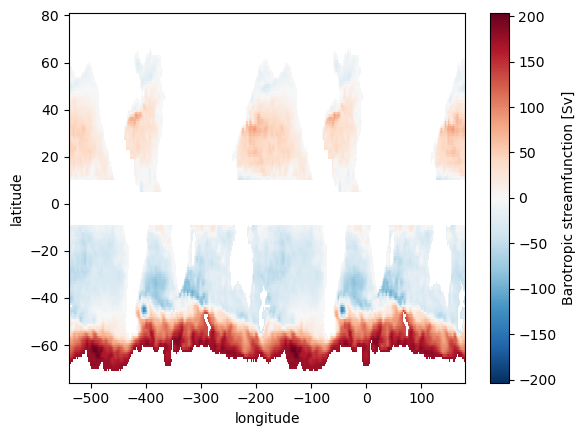

In [54]:
psi_ds["psi"].plot()

#### ANDRO deep currents

Ollitrault, M. and Rannou, J.-P. (2013). ANDRO: An Argo-based deep displacement dataset. Journal of Atmospheric and Oceanic Technology, 30(4):759–788.
http://dx.doi.org/10.1175/JTECH-D-12-00073.1

2026 release: https://doi.org/10.17882/47077 and https://www.seanoe.org/data/00360/47077/

**BUG:** data seems misaligned with land in places

In [55]:
andro_ds = xtile(
    xr.open_dataset(
        '/g/data/ik11/observations/ANDRO_Argo_displacements/2026/127689.nc'
    ).transpose('latitude', 'longitude'))

# calculate speed
andro_ds["speed"] = np.sqrt( andro_ds['mean_u']**2 + andro_ds['mean_v']**2 )/100  # convert cm/s to m/s
andro_ds["speed"].attrs = andro_ds["mean_u"].attrs | {'units': 'm s-1', 'long_name': 'Speed at 1000m'}
del andro_ds["speed"].attrs["Units"]
del andro_ds["speed"].attrs["Name"]

In [56]:
andro_ds["speed"]

<xarray.DataArray 'speed' (latitude: 545, longitude: 1440)> Size: 6MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(545, 1440))
Coordinates:
  * latitude   (latitude) float64 4kB -77.01 -76.9 -76.78 ... 89.49 89.69 89.9
  * longitude  (longitude) float64 12kB -540.0 -539.5 -539.0 ... 179.0 179.5
Attributes:
    units:      m s-1
    long_name:  Speed at 1000m

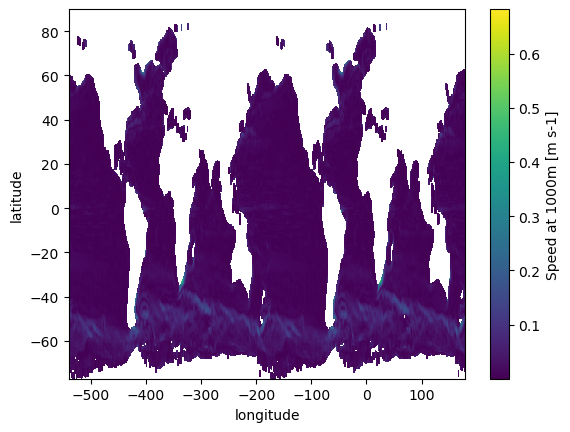

In [57]:
andro_ds["speed"].plot()

#### SSH variance

#### Drifters
Drifter surface speed data from Kiss et al fig 24 was from [Laurindo et al 2017](http://dx.doi.org/10.1016/j.dsr.2017.04.009), downloaded in 2017.

Here we use an updated 2025 version from http://www.aoml.noaa.gov/phod/dac/dac_meanvel.php instead.

In [58]:
drifters_ds = xtile(
    xr.open_dataset(
        '/g/data/ik11/observations/Laurindo_et_al_surface_current/v3.11/drifter_annualmeans.nc'
    ).transpose('latitude', 'longitude'))

# calculate speed
drifters_ds["speed"] = np.sqrt( drifters_ds['U']**2 + drifters_ds['V']**2 ).compute()
drifters_ds["speed"].attrs = drifters_ds["U"].attrs | {'units': 'm s-1', 'long_name': 'Surface speed'}

In [59]:
drifters_ds["speed"]

<xarray.DataArray 'speed' (latitude: 632, longitude: 2880)> Size: 15MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(632, 2880))
Coordinates:
  * latitude   (latitude) float64 5kB -72.88 -72.62 -72.38 ... 84.38 84.62 84.88
  * longitude  (longitude) float64 23kB -539.9 -539.6 -539.4 ... 179.6 179.9
Attributes:
    colorBarMaximum:  1.5
    colorBarMinimum:  -1.5
    long_name:        Surface speed
    units:            m s-1
    valid_max:        1.2255
    valid_min:        -1.2494

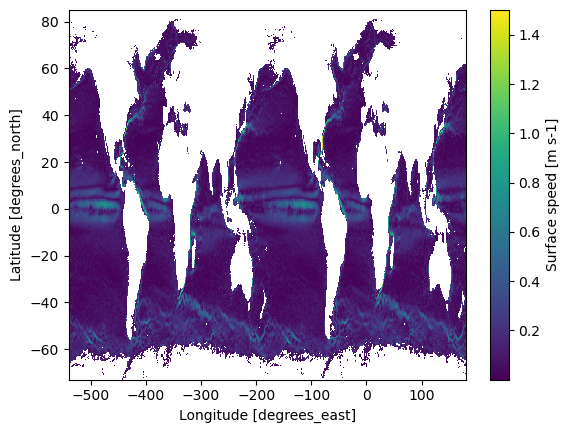

In [60]:
drifters_ds["speed"].plot()

### Define regions
Match [Kiss et al 2020](https://doi.org/10.5194/gmd-13-401-2020) figs 16, 17, 21, 22, 24

Coordinate ranges copied from
- https://github.com/COSIMA/ACCESS-OM2-1-025-010deg-report/blob/master/figures/BarotropicStreamfunction/BarotropicStreamfunction.ipynb
- https://github.com/COSIMA/ACCESS-OM2-1-025-010deg-report/blob/master/figures/Southwest_Atlantic/Southwest_atlantic_analysis_v3.ipynb


Text(0.5, 1.0, 'Regions (BUG: incorrect shapes north of 65°N)')

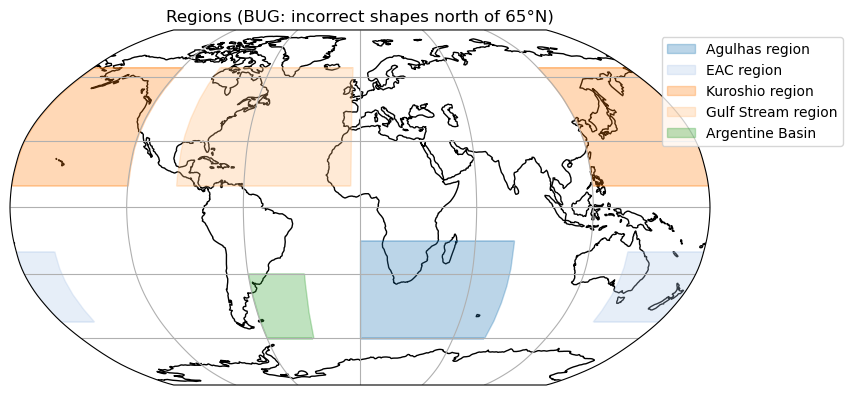

In [61]:
regions = { # [minx, maxx, miny, maxy], using model longitude range (-280 to 80)
    "Agulhas region": [0, 80, -60, -15],  # fig 16 in Kiss et al 2020
    "EAC region": [-220, -160, -52, -20],  # fig 17 in Kiss et al 2020
    "Kuroshio region": [-240, -120, 10, 65],  # fig 21 in Kiss et al 2020
    "Gulf Stream region": [-95, -5, 10, 65],  # fig 22 in Kiss et al 2020
    "Argentine Basin": [-60, -30, -60, -30],  # fig 24 in Kiss et al 2020
    # "Global": [-280, 80, -90, 90],
    # "Arctic": [-280, 80, 65, 90],
    # "Southern Ocean": [-280, 80, -82, -63],
    # "ACC": [-280, 80, -63, -45],
    # "Southern Pacific": [-210, -70, -45, -20],
    # "Tropical Pacific": [-240, -100, -20, 20],
    # "North Pacific": [-240, -100, 20, 65],
    # "South Atlantic": [-60, 20, -45, -20],
    # "Tropical Atlantic": [-70, 20, -20, 20],
    # "North Atlantic": [-100, 0, 20, 65],
    # "Indian": [30, 120, -45, 20],
    # "Aegean Sea": [18, 27.5, 34, 44],
    # "Black Sea": [27.5, 43, 40.5, 48],
    # "Baltic Sea": [13, 30, 53, 58],
    # "Mediterranean Sea": [0, 35, 31, 41],
    # "Red Sea": [33, 44, 12, 29],
    # "Persian Gulf": [47, 56, 24, 31],
    # "White Sea": [31, 41, 63, 68],
}
regions = {k: dict(zip(["minx", "maxx", "miny", "maxy"], v)) for k, v in regions.items()}  # convert to dicts

for r, d in regions.items():
    for k, x in d.items():
        if k in ["minx", "maxx"] and x != max(-280, min(x, 80)):
            raise ValueError(f"{r} {k} = {x} is outside the range -280 to 80")

fig = plt.figure(figsize=(10, 4))

colors = mpl.color_sequences['tab20']
try:  # set Global color to white 
    colors[list(regions.keys()).index("Global")] = (1, 1, 1)
except ValueError:
    pass

ax = plt.axes(position=[0.05,0.05,0.7,0.9], projection=ccrs.Robinson())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=False)

legend_elements = []
for i, (region, limits) in enumerate(regions.items()):
    ax.add_geometries([geometry.box(**limits)], crs=ccrs.PlateCarree(), color=colors[i], alpha=0.3)
    legend_elements.append(Patch(color=colors[i], alpha=0.3, label=region))

ax.legend(handles=legend_elements, bbox_to_anchor=(1.2, 1.00))
plt.title("Regions (BUG: incorrect shapes north of 65°N)")

## Calculate speed at particular depths

### Interpolate onto NE corner points

In [62]:
# new dict containing interpolated time-mean dataarrays
interp_axis = {"uo": "Y", "vo": "X"}  # interpolate to NE corner to match B-grid OM2 data
coord = {"uo": "yh", "vo": "xh"}
for vname in interp_axis:
    data[vname+"_ne"] = dict()
    for expt, da in data[vname].items():
        v = grid.interp(da.chunk(chunks={coord[vname]: -1}),
                        interp_axis[vname], boundary="extend")
        v = v.assign_coords({
            "z_l": da.z_l,
            "geolon_c": static.geolon_c,
            "geolat_c": static.geolat_c})
        data[vname+"_ne"][expt] = v

In [63]:
# calculate speed at given depths, using uo, vo interpolated to NE corner of cells (B-grid vel point)
import dask
depths = [0, 1000]
for depth in depths:
    data[f"speed_{depth}"] = dict()
for expt in om3datastores:
    for depth in depths:
        u = data['uo_ne'][expt].sel(z_l=depth, method='nearest')
        v = data['vo_ne'][expt].sel(z_l=depth, method='nearest')
        data[f"speed_{depth}"][expt] = np.sqrt(u**2 + v**2 )

# compute all speeds in ONE pass (shares the uo/vo time-mean graph),
# otherwise every region plot re-reads the full uo/vo record
(computed,) = dask.compute({f"speed_{d}": dict(data[f"speed_{d}"]) for d in depths})
for d in depths:
    data[f"speed_{d}"] = computed[f"speed_{d}"]

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 53.49 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


## Plot

In [64]:
blue_marble = plt.imread('/g/data/ik11/grids/BlueMarble.tiff')
blue_marble_extent = (-180, 180, -90, 90)

Agulhas region 0 80 -60 -15
EAC region -220 -160 -52 -20
Kuroshio region -240 -120 10 65
Gulf Stream region -95 -5 10 65
Argentine Basin -60 -30 -60 -30


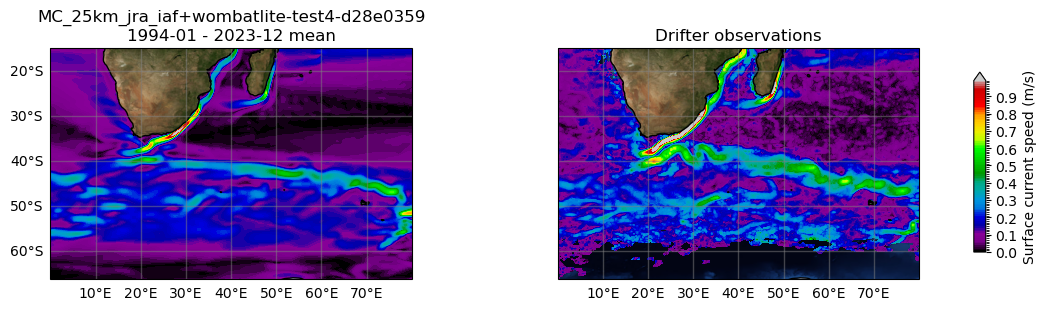

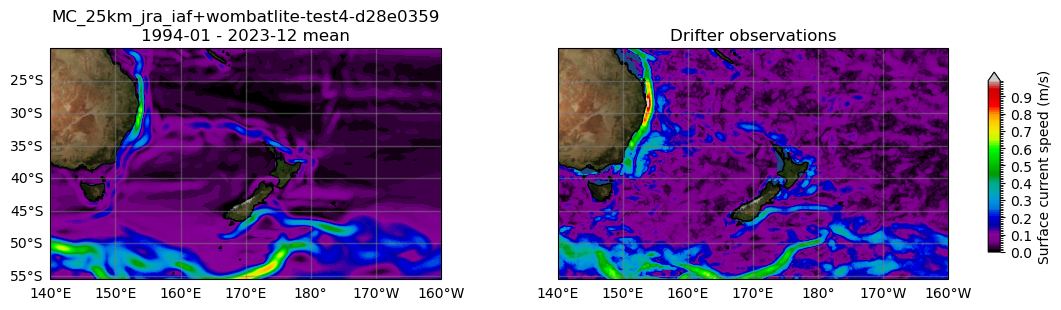

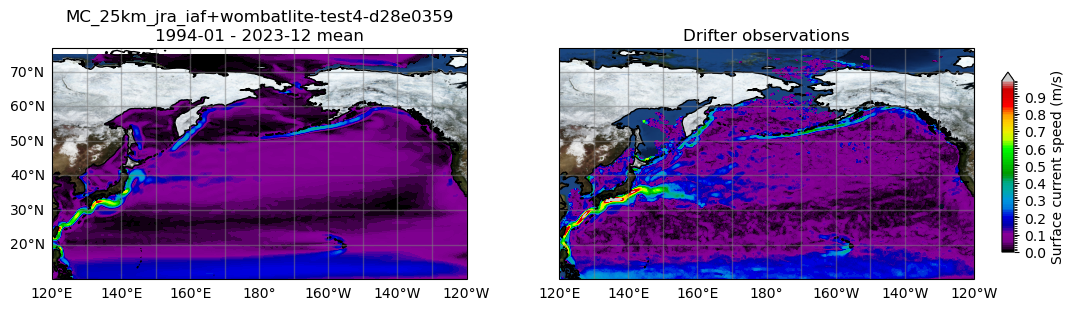

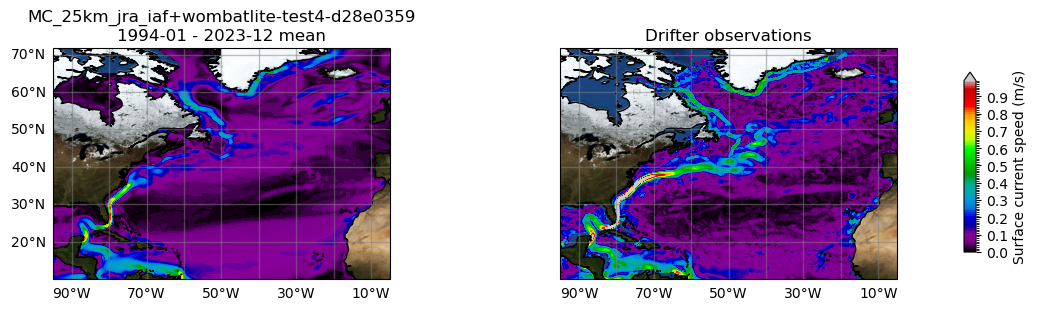

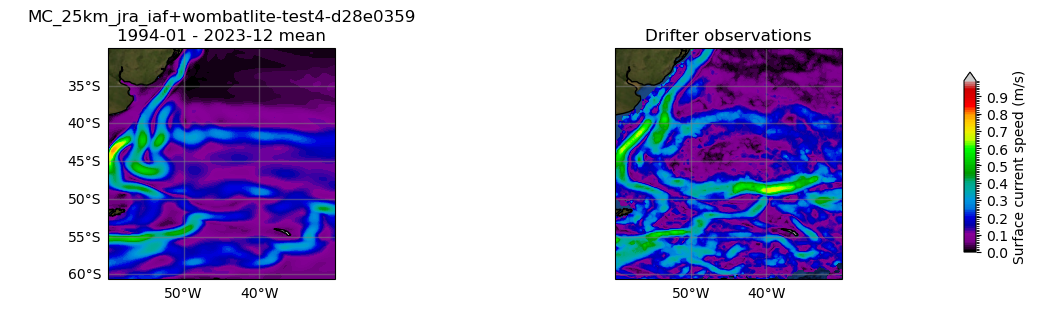

In [65]:
# plot surface current speed
margin = 10
cmp = plt.get_cmap('nipy_spectral')
clev1 = np.arange(0, 1.0, 0.01)
for region, bounds in regions.items():
    # if region == "Kuroshio region":
    #     break
    # if region != "Argentine Basin":
    #     continue
    minx, maxx, miny, maxy = bounds.values()
    print(region, minx, maxx, miny, maxy)
    xslice = slice(minx-margin, maxx+margin)
    yslice = slice(miny-margin, maxy+margin)
    nrows = 1 # TODO
    ncols = len(data["speed_0"]) + 1
    proj = ccrs.PlateCarree(central_longitude=(minx+maxx)/2)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 3*nrows),
                             subplot_kw=dict(projection=proj,
                                             frame_on=False))
    # plot model
    for i, (expt, da) in enumerate(data["speed_0"].items(), start=1):
        ax = plt.subplot(nrows, ncols, i, projection=proj)
    
        d = da.sel(xq=xslice, yq=yslice)
        p1 = d.plot.contourf(cmap=cmp,
                             levels=clev1,
                             add_colorbar=False,
                             extend='max',
                             transform=ccrs.PlateCarree(),
                            )
        p1.cmap.set_over(color=cmp(255), alpha=None)
        plt.title(f"{expt}\n{datestart.strftime('%Y-%m')} - {datestop.strftime('%Y-%m')} mean")
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color='gray', alpha=0.5, linestyle='-')
        gl.top_labels = False
        gl.right_labels = False
        if i > 1:
            gl.left_labels = False
        gl.xlocator = mticker.FixedLocator(np.arange(-270, 180, 10))
        plt.imshow(
            blue_marble,
            extent=blue_marble_extent,
            transform=ccrs.PlateCarree(),
            origin="upper")
        ax.coastlines(resolution="50m")
        ax.set_extent(bounds.values())
    
    # plot obs
    ax = plt.subplot(nrows, ncols, ncols, projection=proj)

    d = drifters_ds["speed"].sel(longitude=xslice, latitude=yslice)
    p1 = d.plot.contourf(cmap=cmp,
                         levels=clev1,
                         add_colorbar=False,
                         extend='max',
                         transform=ccrs.PlateCarree(),
                        )
    p1.cmap.set_over(color=cmp(255), alpha=None)
    plt.title("Drifter observations")
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='-')
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(-270, 180, 10))
    plt.imshow(
        blue_marble,
        extent=blue_marble_extent,
        transform=ccrs.PlateCarree(),
        origin="upper")
    ax.coastlines(resolution="50m")
    ax.set_extent(bounds.values())

    ax1 = plt.axes([0.92, 0.2, 0.01, 0.6])
    cb = plt.colorbar(p1, cax=ax1, orientation='vertical', pad=.05)
    cb.ax.set_ylabel('Surface current speed (m/s)')

Agulhas region 0 80 -60 -15
EAC region -220 -160 -52 -20
Kuroshio region -240 -120 10 65
Gulf Stream region -95 -5 10 65
Argentine Basin -60 -30 -60 -30


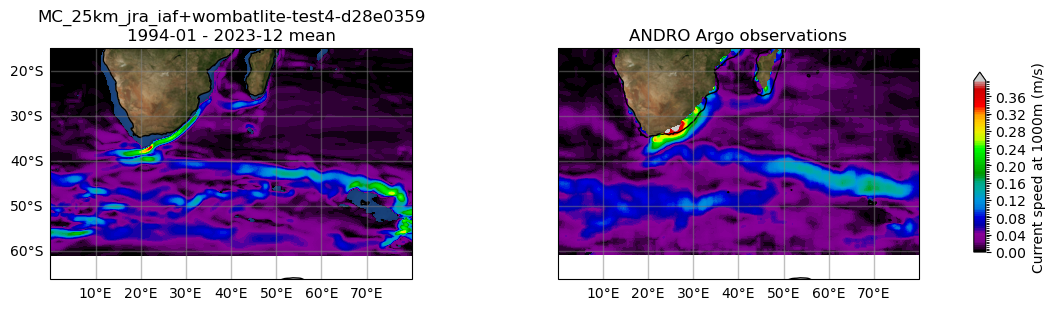

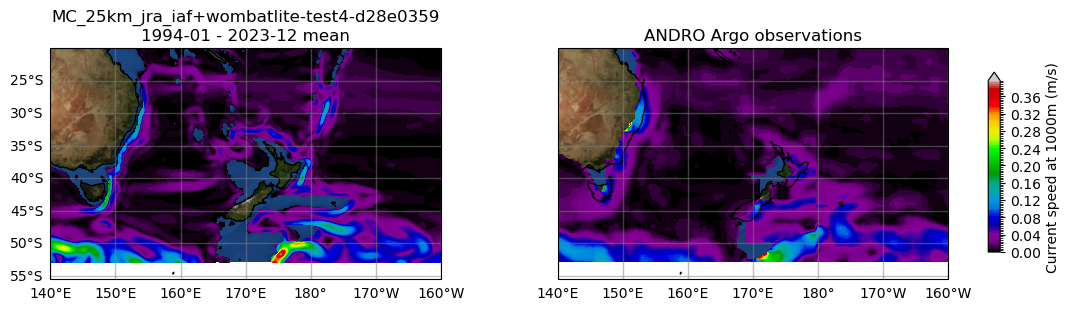

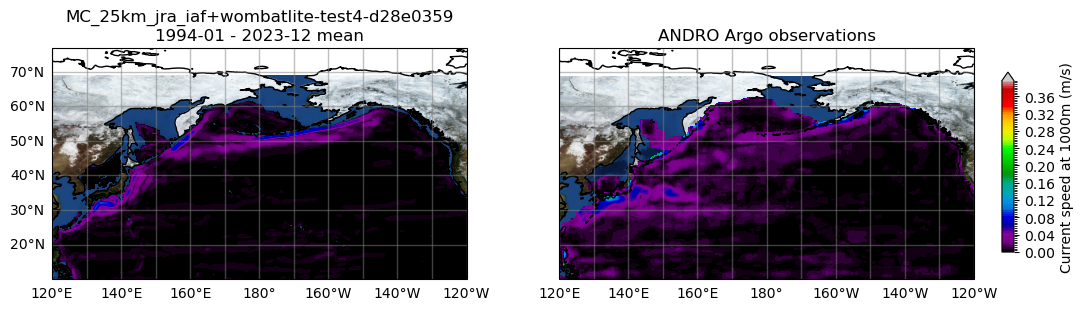

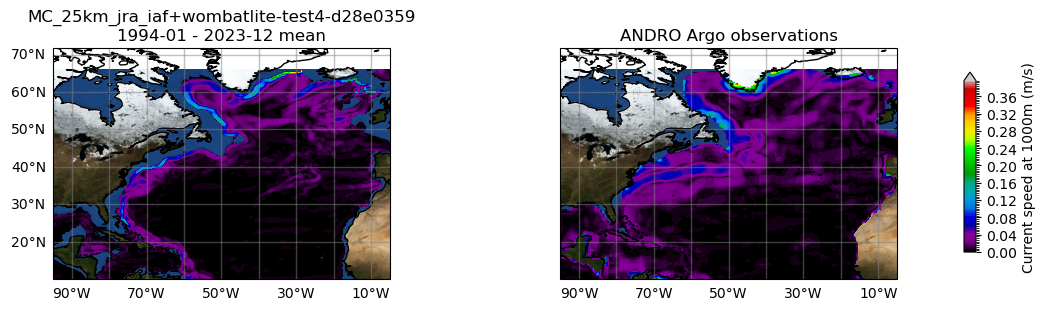

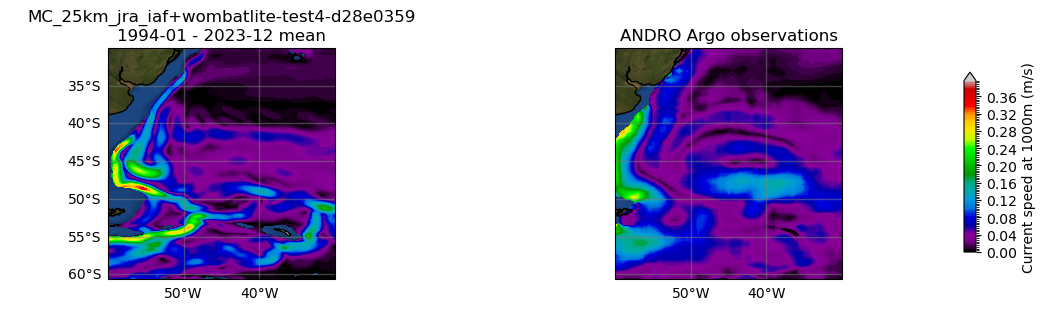

In [66]:
# plot 1000m current speed
margin = 1
cmp = plt.get_cmap('nipy_spectral')
clev1 = np.arange(0, 1.0, 0.01) * 0.4
for region, bounds in regions.items():
    # if region != "Argentine Basin":
    #     continue
    minx, maxx, miny, maxy = bounds.values()
    print(region, minx, maxx, miny, maxy)
    xslice = slice(minx-margin, maxx+margin)
    yslice = slice(miny-margin, maxy+margin)
    nrows = 1 # TODO
    ncols = len(data["speed_0"]) + 1
    proj = ccrs.PlateCarree(central_longitude=(minx+maxx)/2)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 3*nrows),
                             subplot_kw=dict(projection=proj,
                                             frame_on=False))
    # plot model
    for i, (expt, da) in enumerate(data["speed_1000"].items(), start=1):
        ax = plt.subplot(nrows, ncols, i, projection=proj)
    
        d = da.sel(xq=xslice, yq=yslice)
        p1 = d.plot.contourf(cmap=cmp,
                             levels=clev1,
                             add_colorbar=False,
                             extend='max',
                             transform=ccrs.PlateCarree(),
                            )
        p1.cmap.set_over(color=cmp(255), alpha=None)
        plt.title(f"{expt}\n{datestart.strftime('%Y-%m')} - {datestop.strftime('%Y-%m')} mean")
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color='gray', alpha=0.5, linestyle='-')
        gl.top_labels = False
        gl.right_labels = False
        if i > 1:
            gl.left_labels = False
        gl.xlocator = mticker.FixedLocator(np.arange(-270, 180, 10))
        plt.imshow(
            blue_marble,
            extent=blue_marble_extent,
            transform=ccrs.PlateCarree(),
            origin="upper")
        ax.coastlines(resolution="50m")
        ax.set_extent(bounds.values())
    
    # plot obs
    ax = plt.subplot(nrows, ncols, ncols, projection=proj)

    d = andro_ds["speed"].sel(longitude=xslice, latitude=yslice)
    p1 = d.plot.contourf(cmap=cmp,
                         levels=clev1,
                         add_colorbar=False,
                         extend='max',
                         transform=ccrs.PlateCarree(),
                        )
    p1.cmap.set_over(color=cmp(255), alpha=None)
    plt.title("ANDRO Argo observations")
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='-')
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(-270, 180, 10))
    plt.imshow(
        blue_marble,
        extent=blue_marble_extent,
        transform=ccrs.PlateCarree(),
        origin="upper")
    ax.coastlines(resolution="50m")
    ax.set_extent(bounds.values())

    ax1 = plt.axes([0.92, 0.2, 0.01, 0.6])
    cb = plt.colorbar(p1, cax=ax1, orientation='vertical', pad=.05)
    cb.ax.set_ylabel('Current speed at 1000m (m/s)')